<a href="https://colab.research.google.com/github/Faspeice/ml/blob/lr2/lr2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Задание 2

# Визуальный анализ данных

**Цель работы**: изучить программные средства, используемые для визуализации наборов данных

Выполним анализ набора данных `customer_churn`. Набор представляет собой данные об активности клиентов маректинговой компании. Набор данных подходит для обучения моделей логистической регрессии, моделей классификации. Требуется выяснить, какие клиенты более всего подвергают риску увольнения менежера по работе с клиентами. Набор данных включает следующие атрибуты:

- **Name** – имя последнего контактного лица в компании.  
- **Age** – возраст клиента.  
- **Total Purchase** – общее количество купленных объявлений.  
- **Account Manager** – двоичный код (0 – нет менеджера, 1 – назначен менеджер по работе с клиентами).  
- **Years** – всего лет в качестве клиента.  
- **Num sites** – число веб-сайтов, которые используют сервис.  
- **Onboard date** – дата, когда имя последнего контактного лица было указано в boarded.  
- **Location** – адрес штаб-квартиры клиента.  
- **Company** – название компании-клиента.  
- **Churn** – ушел или нет (целевая переменная).

 ## 1. Импортируем необходимые библиотеки

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
%matplotlib inline

## 2. Импортируем набор данных из файла customer_churn.csv и поместим его в объект DataFrame

In [2]:
url = "https://raw.githubusercontent.com/faspeice/ml/lr2/customer_churn.csv"
df = pd.read_csv(url)

# Оставляем только клиентов, которым был назначен менедер
data = df[df['Account_Manager'] == 1].copy()
data = data.drop(columns=['Account_Manager'])

data.head(10)

,Names,Age,Total_Purchase,Years,Num_Sites,Onboard_date,Location,Company,Churn
6,Eric Butler,44.0,11331.58,5.23,11.0,2016-12-05 03:35:43,"4846 Savannah Road West Justin, IA 87713-3460",Reynolds-Sheppard,1
7,Zachary Walsh,32.0,9885.12,6.92,9.0,2006-03-09 14:50:20,"25271 Roy Expressway Suite 147 Brownport, FM 5...",Singh-Cole,1
8,Ashlee Carr,43.0,14062.60,5.46,11.0,2011-09-29 05:47:23,"3725 Caroline Stravenue South Christineview, M...",Lopez PLC,1
9,Jennifer Lynch,40.0,8066.94,7.11,11.0,2006-03-28 15:42:45,"363 Sandra Lodge Suite 144 South Ann, WI 51655...",Reed-Martinez,1
10,Paula Harris,30.0,11575.37,5.22,8.0,2016-11-13 13:13:01,Unit 8120 Box 9160 DPO AA 43432,"Briggs, Lamb and Mathews",1
11,Bruce Phillips,45.0,8771.02,6.64,11.0,2015-05-28 12:14:03,Unit 1895 Box 0949 DPO AA 40249,Figueroa-Maynard,1
12,Craig Garner,45.0,8988.67,4.84,11.0,2011-02-16 08:10:47,897 Kelley Overpass Suite 349 West Rebekahport...,Abbott-Thompson,1
13,Nicole Olson,40.0,8283.32,5.10,13.0,2012-11-22 05:35:03,"11488 Weaver Cape Hernandezberg, WI 63417-8544","Smith, Kim and Marshall",1
14,Harold Griffin,41.0,6569.87,4.30,11.0,2015-03-28 02:13:44,"1774 Peter Row Apt. 712 New Autumn, MT 18782","Snyder, Lee and Morris",1
15,James Wright,38.0,10494.82,6.81,12.0,2015-07-22 08:38:40,"45408 David Path East Kimberlyshire, HI 54903-...",Sanders-Pierce,1


## 3. Получим сводную информацию по датафрейму

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 433 entries, 6 to 899
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Names           433 non-null    object 
 1   Age             433 non-null    float64
 2   Total_Purchase  433 non-null    float64
 3   Years           433 non-null    float64
 4   Num_Sites       433 non-null    float64
 5   Onboard_date    433 non-null    object 
 6   Location        433 non-null    object 
 7   Company         433 non-null    object 
 8   Churn           433 non-null    int64  
dtypes: float64(4), int64(1), object(4)
memory usage: 50.0+ KB


## 4. Визуализация количественных признаков

Для каждого количественного признака построим гистограмму и диаграмму "Ящик с усами"

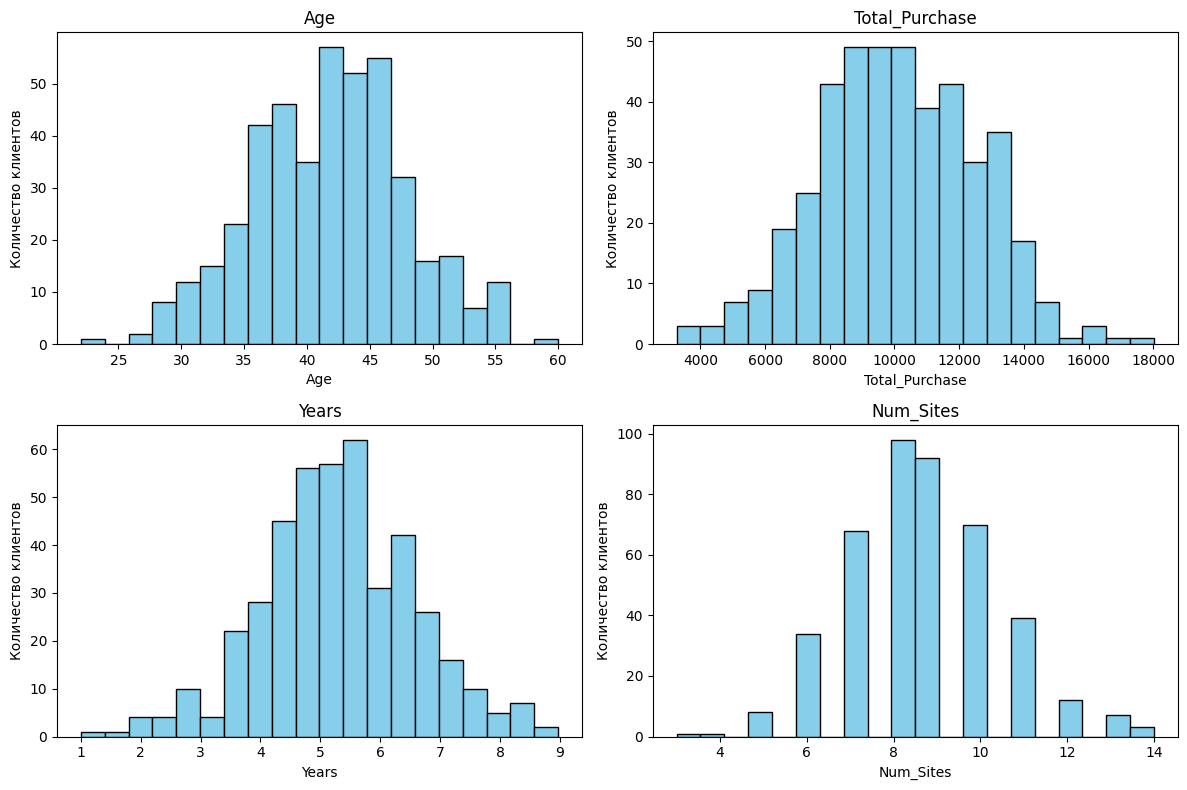

In [4]:
numeric_cols = ['Age', 'Total_Purchase', 'Years', 'Num_Sites']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(data[col], bins=20, color='skyblue', edgecolor='black')
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Количество клиентов")

plt.tight_layout()
plt.show()

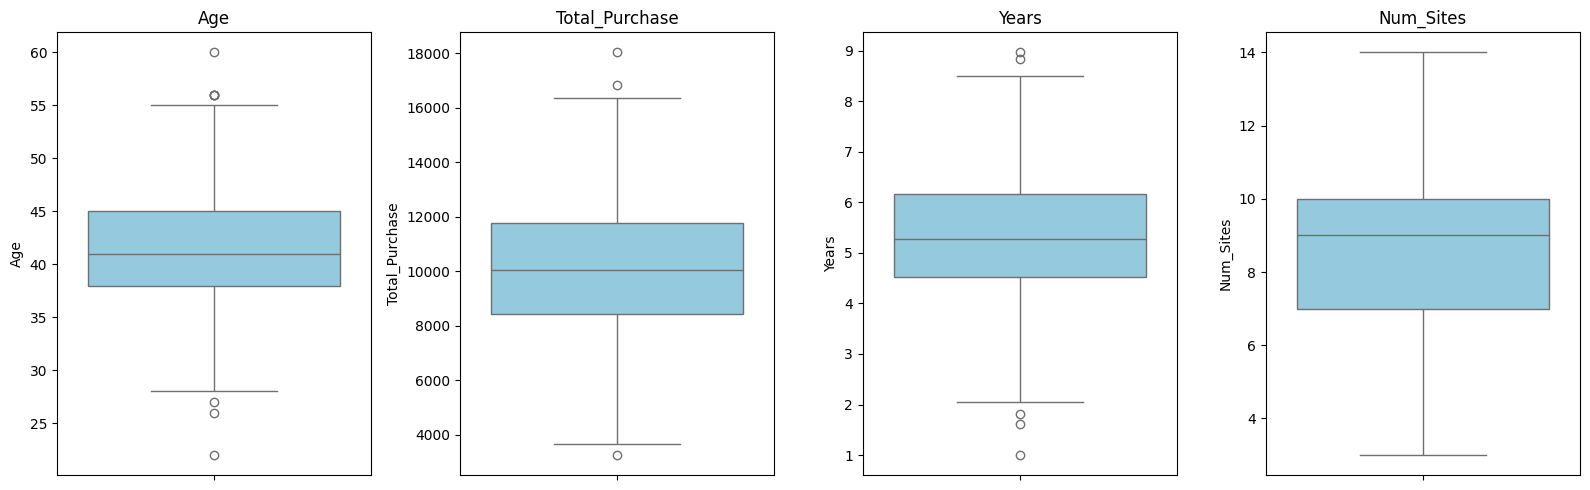

In [5]:

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for i, col in enumerate(numeric_cols):
    sns.boxplot(y=data[col], ax=axes[i], color='skyblue')
    axes[i].set_title(col)
plt.tight_layout()
plt.show()


Построим так же гистограммы с разбивкой по целевой переменной

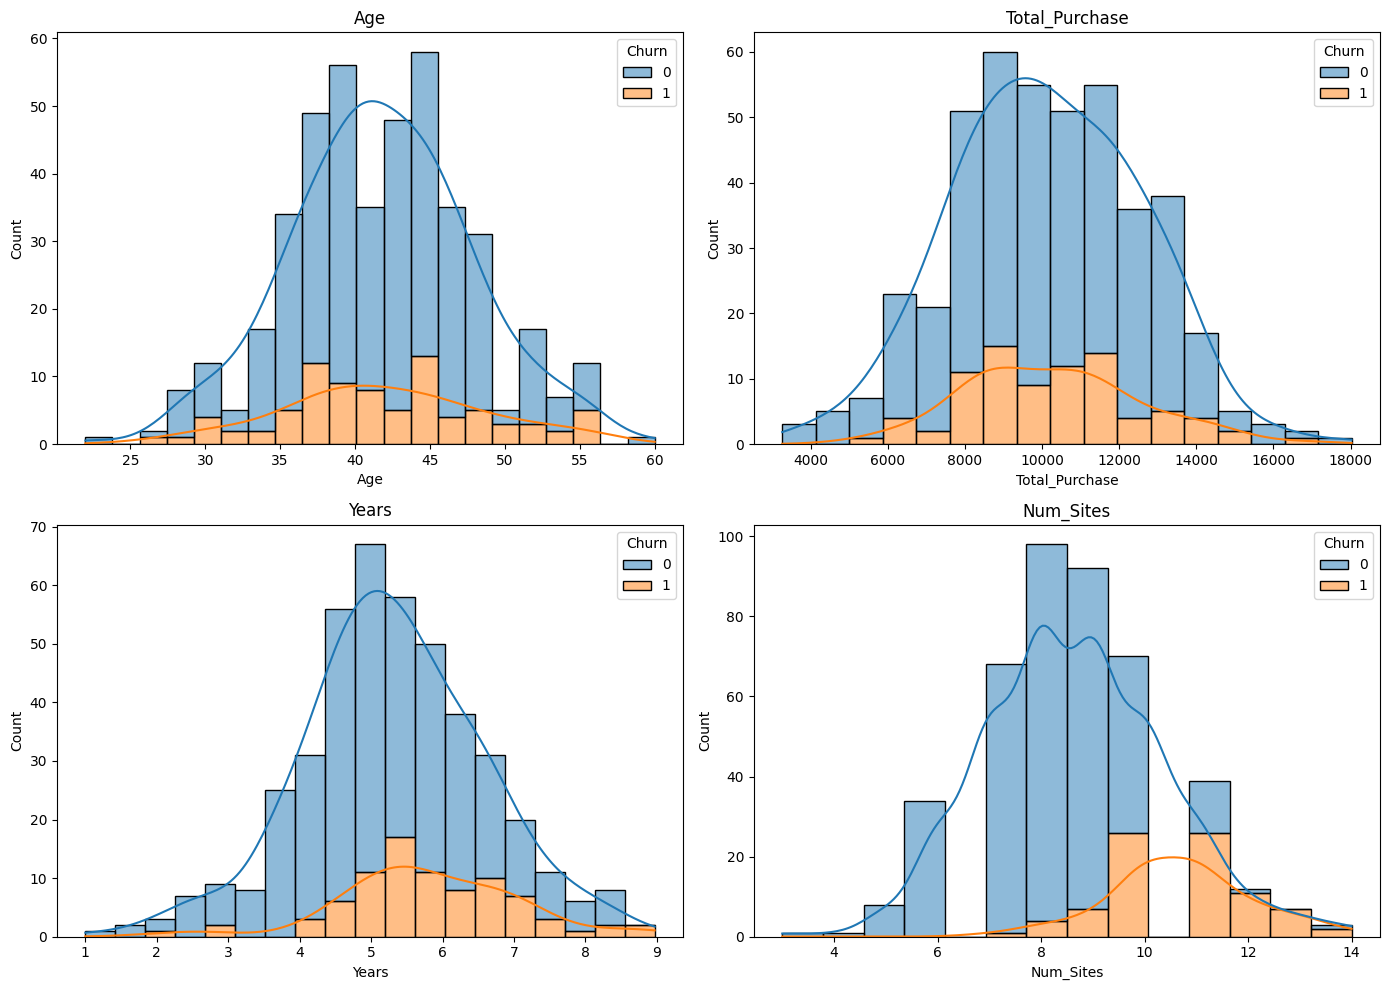

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.histplot(data=data, x=col, hue='Churn', kde=True, ax=axes[i], multiple="stack")
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

## 5. Визуализация категориальных признаков

Построим столбчатые диаграммы, показывающие:

- распределение клиентов по целевой переменной **Churn** (ушёл/остался);  
- количество клиентов в **15 самых популярных компаниях**;  
- количество клиентов по **3 самым распространённым адресам**.

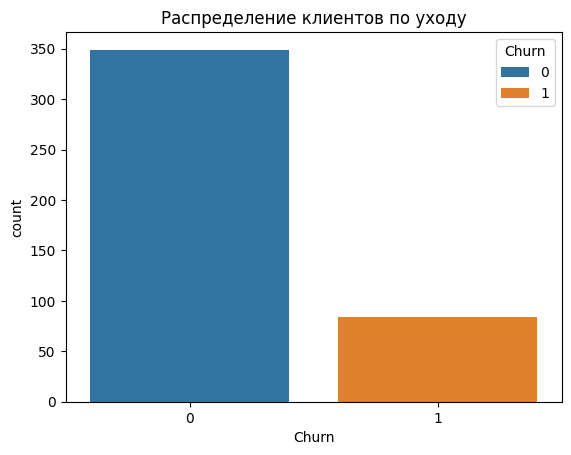

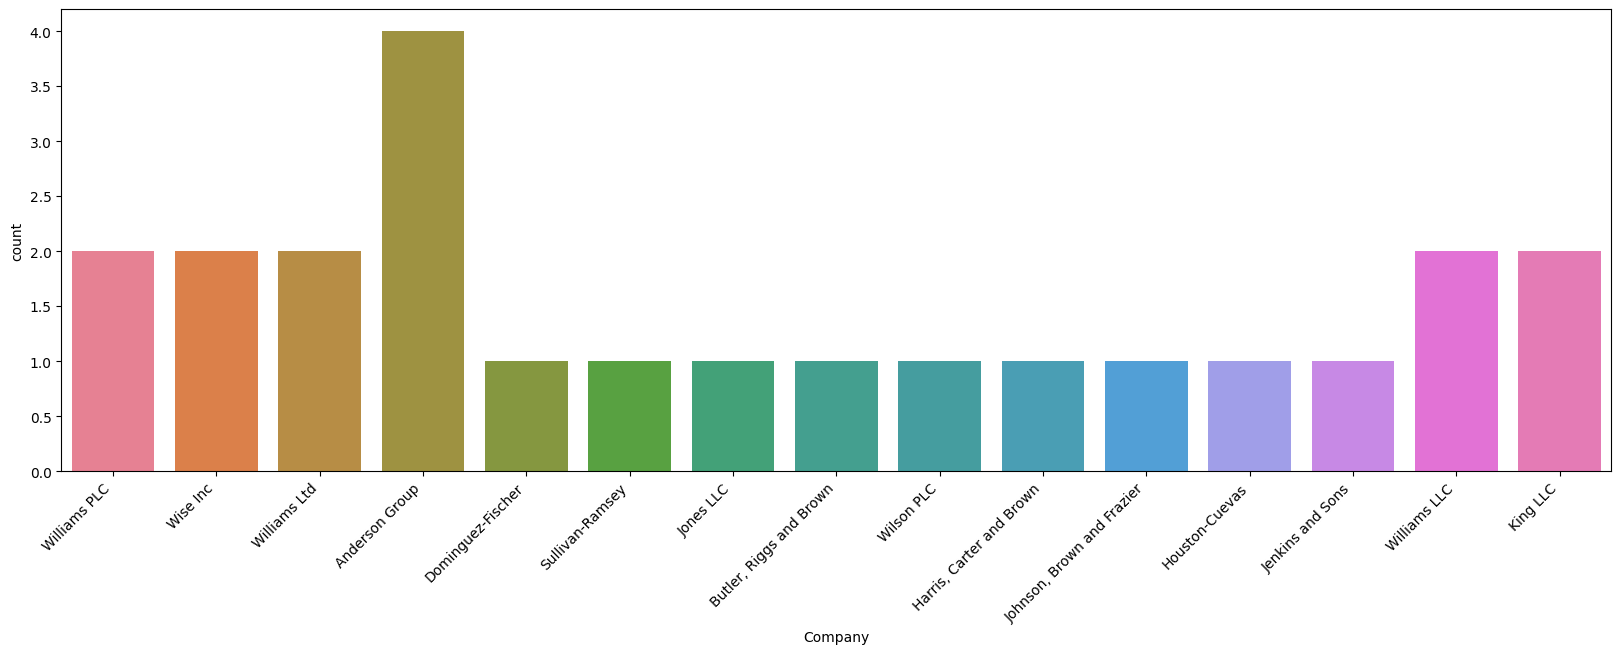

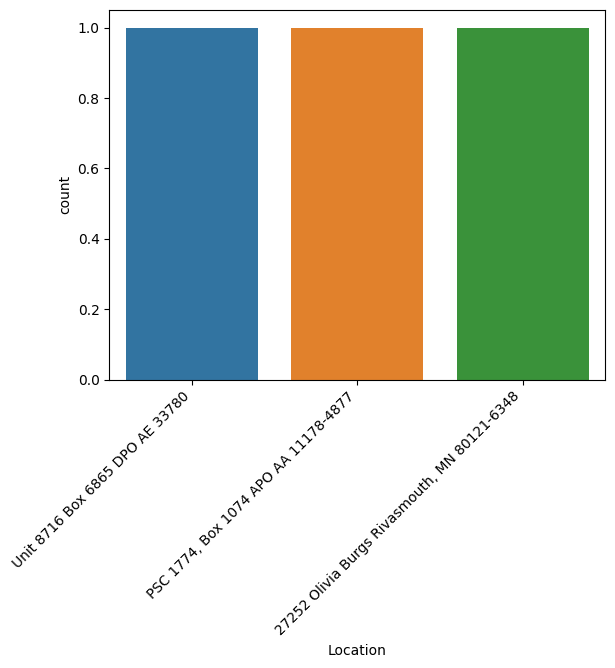

In [7]:

plt.title("Распределение клиентов по уходу")
sns.countplot(x='Churn', hue='Churn', data=data)
plt.show()

fig = plt.subplots(figsize = (20,6))
sns.countplot(data[data['Company'].isin(data['Company'].value_counts().head(15).index)], x='Company',hue='Company')
plt.xticks(rotation=45, ha='right')
plt.show()


sns.countplot(data[data['Location'].isin(data['Location'].value_counts().head(3).index)], x='Location',hue='Location')
plt.xticks(rotation=45, ha='right')
plt.show()

## 6. Визуализация взаимосвязанных признаков

Для всех колчественных данных используем попарное сравнение признаков с разбивкой по целевой переменной

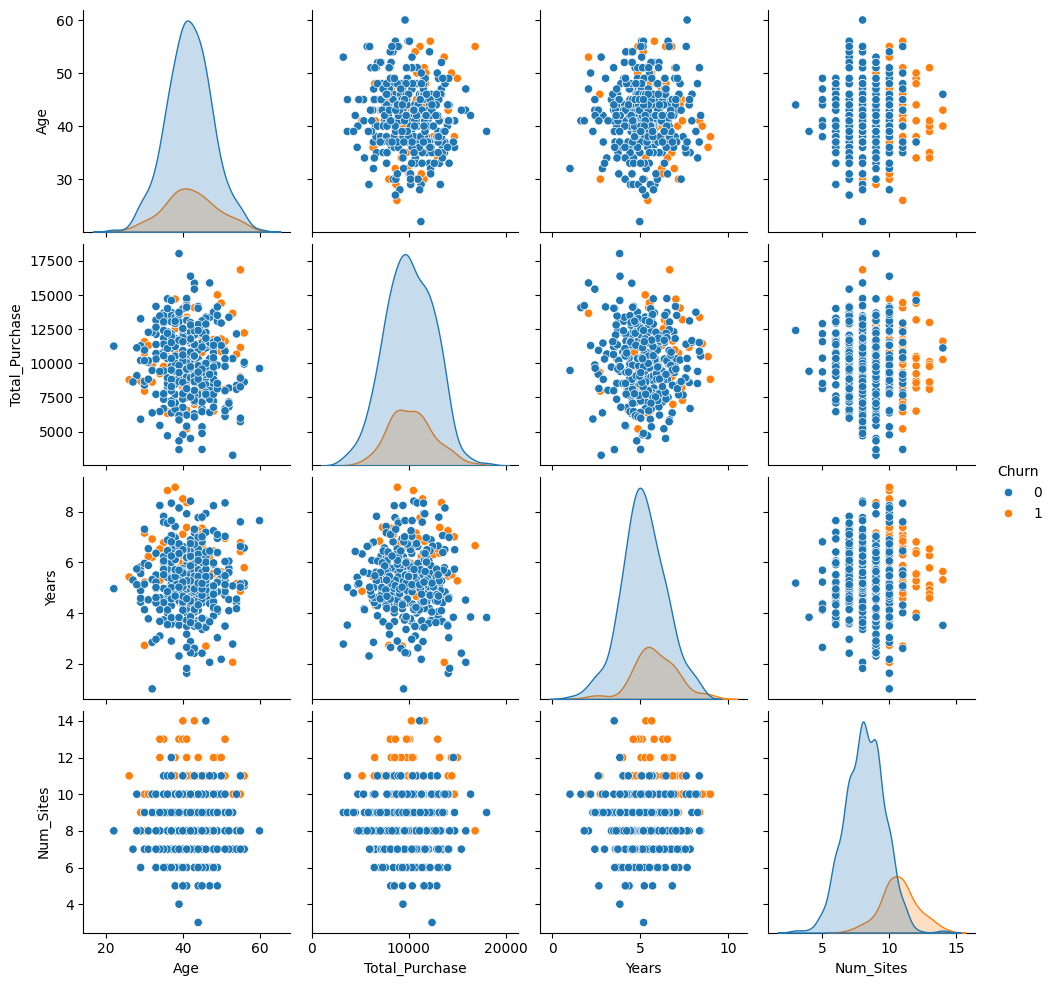

In [8]:
numeric_cols = ['Age', 'Total_Purchase', 'Years', 'Num_Sites']
sns.pairplot(data[numeric_cols + ['Churn']],hue='Churn')

Более  подробно попарно рассмотрим признаки Years + Num_Sites и Years + Total_Purchase

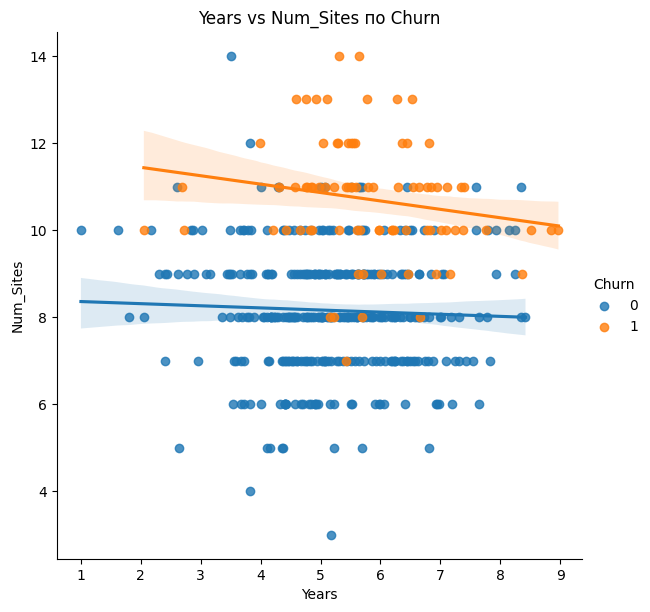

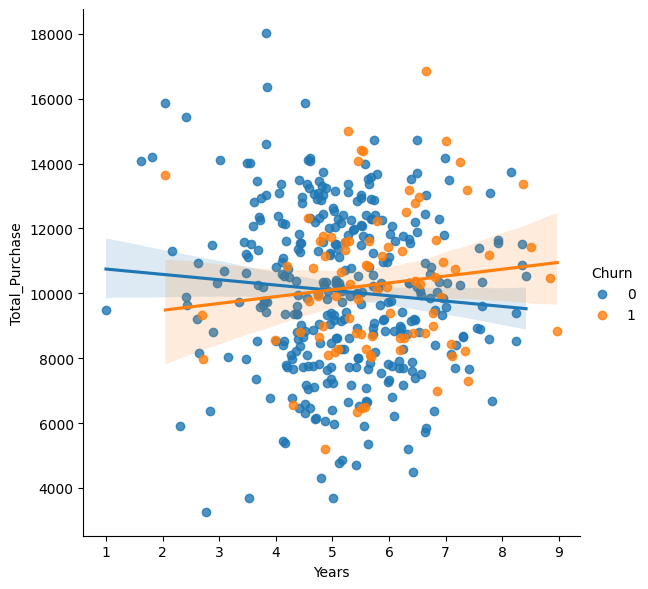

In [9]:
sns.lmplot(data=data, x='Years', y='Num_Sites',  hue='Churn', height=6)
plt.title('Years vs Num_Sites по Churn')
plt.show()
sns.lmplot(data=data, x='Years', y='Total_Purchase',  hue='Churn', height=6)
plt.show()

На графиках видно, что клиенты явно группируются в зависимости от количества сайтов.

## 7. Корреляция признаков

Построим heatmap для визуализации корреляции признаков

<Axes: >

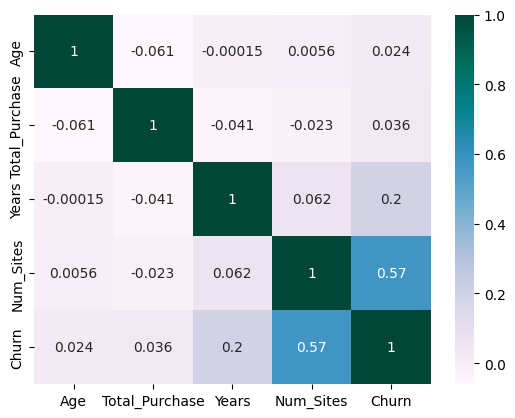

In [10]:
sns.heatmap(data.corr(numeric_only = True), cmap=plt.cm.PuBuGn, annot=True)

**Вывод**
: Среди клиентов, закреплённых за менеджерами, наиболее подвержены оттоку те, у кого большое количество сайтов.
Это означает, что менеджеры, работающие с клиентами, использующими множество сайтов, находятся в группе повышенного риска увольнения, поскольку их клиенты уходят значительно чаще.